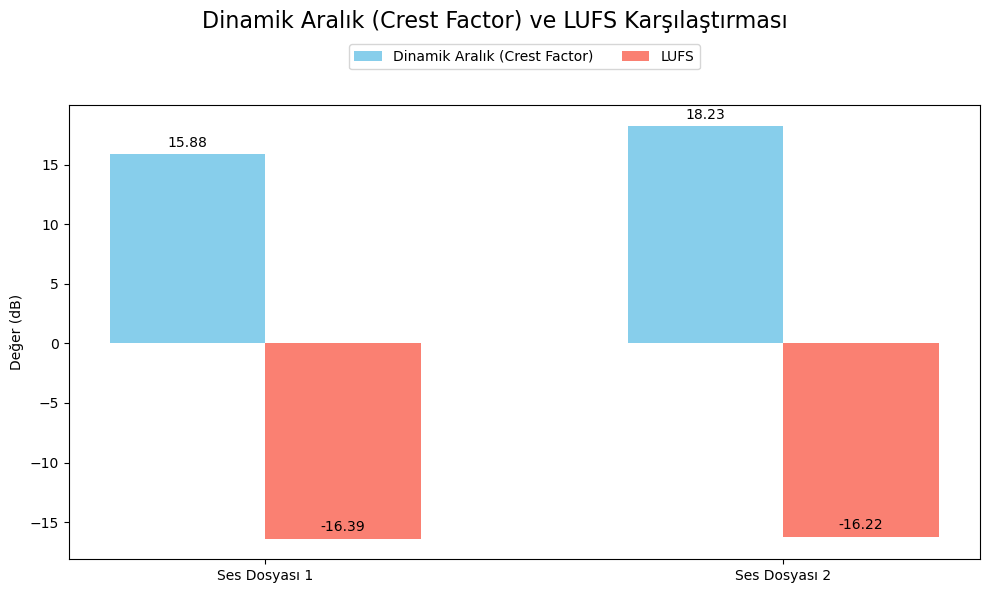

In [24]:
import matplotlib.pyplot as plt # Grafik çizimi için matplotlib kütüphanesi
import numpy as np # Sayısal hesaplamalar için numpy kütüphanesi
import librosa # Ses dosyası yükleme ve işleme için
import pyloudnorm as pyln # LUFS (Loudness Units Full Scale) analizi için

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/processed/teletronix_white_noise.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/processed/urei_white_noise.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükleme
wave_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükleme

# LUFS analiz aracı
meter = pyln.Meter(sr_1) # LUFS ölçer (örnekleme oranı dosyanın orijinal değeriyle uyumlu)

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükle (orijinal örnekleme oranıyla)
wave_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükle (orijinal örnekleme oranıyla)

# Dinamik Aralık (Crest Factor) Hesaplama
max_1 = np.max(np.abs(wave_1)) # İlk sesin maksimum genlik değeri
rms_1 = np.sqrt(np.mean(wave_1 ** 2)) # İlk sesin RMS değeri
max_2 = np.max(np.abs(wave_2)) # İkinci sesin maksimum genlik değeri
rms_2 = np.sqrt(np.mean(wave_2 ** 2)) # İkinci sesin RMS değeri

# Crest Factor (Dinamik Aralık) hesapla
cf_1 = 20 * np.log10(max_1 / rms_1) if rms_1 > 0 else -np.inf # İlk ses için dinamik aralık
tcf_2 = 20 * np.log10(max_2 / rms_2) if rms_2 > 0 else -np.inf # İkinci ses için dinamik aralık

# LUFS Hesaplama
lufs_1 = meter.integrated_loudness(wave_1) # İlk sesin LUFS değeri
lufs_2 = meter.integrated_loudness(wave_2) # İkinci sesin LUFS değeri

# Grafik Çizimi
fig, ax = plt.subplots(figsize=(10, 6)) # Grafik figürü oluşturma
x = np.arange(2) # X ekseni konumları
width = 0.3 # Çubuk genişliği

# Çubuk grafiğini çizdirme ve etiketleri ekleme
bar1 = ax.bar(x - width/2, [cf_1, tcf_2], width, label="Dinamik Aralık (Crest Factor)", color='skyblue')  # Dinamik aralık sütunları
bar2 = ax.bar(x + width/2, [lufs_1, lufs_2], width, label="LUFS", color='salmon')  # LUFS sütunları

# Sütunların üzerine değer etiketlerini ekleme
for bars in [bar1, bar2]: # Her sütun grubu için değerler
    for bar in bars:
        height = bar.get_height() # Sütunların yüksekliği
        ax.annotate(f'{height:.2f}', # Sayısal değer
                    xy=(bar.get_x() + bar.get_width() / 2, height), # Etiketin konumu
                    xytext=(0, 3), # Y ekseninden 3 birim yukarı
                    textcoords="offset points", # Konum için birim tipi
                    ha='center', va='bottom') # Hizalama

# Eksen etiketleri ve başlıkları
ax.set_ylabel("Değer (dB)") # Y ekseni etiketi
ticks = [label_1, label_2] # X ekseni etiketleri
ax.set_xticks(x) # X ekseni konumlarını ayarlama
ax.set_xticklabels(ticks) # X ekseni isimlerini uygulama
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2) # Açıklama kutusunu üst merkeze yerleştir

# Grafik düzenini ayarla ve gösterme
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Yerleşimi optimize etme
plt.suptitle("Dinamik Aralık (Crest Factor) ve LUFS Karşılaştırması", fontsize=16) # Başlık
plt.show() # Grafiği gösterme